# 🚢 Titanic ML — Full Pipeline & RandomForest Baseline

**Competition:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic)  
**Goal:** Predict which passengers survived the Titanic shipwreck.  
**Metric:** Binary classification accuracy on the test set.

---

> **Kernel:** Make sure you have selected the `Python (titanic-ml)` kernel before running any cells.
> In VS Code, click the kernel selector in the top-right corner of this notebook.

## 0. ⚙️ Setup & Imports

We import all the required libraries, configure our local path environment, and load our custom `src/` modules.

In [18]:
import os
import sys

# Insert project root to path so we can import src modules
if os.path.basename(os.getcwd()) == "notebooks":
    PROJECT_ROOT = os.path.abspath("..")
else:
    PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.helpers import load_data, save_submission, display_info, set_seed
from src.preprocessing import clean
from src.features import engineer, select_features
from src.model import build_baseline_model, train_model, predict, cross_validate_model, save_model
from src.evaluate import (
    accuracy_score,
    print_classification_report,
    plot_confusion_matrix,
    plot_feature_importance,
    compare_models,
    roc_auc
)

set_seed(42)
%matplotlib inline

[seed] Random seed set to 42


## 1. 📂 Load Data

We load the train and test CSV datasets using our helper function.

In [19]:
train_raw = load_data(os.path.join(PROJECT_ROOT, "data", "train.csv"))
test_raw = load_data(os.path.join(PROJECT_ROOT, "data", "test.csv"))

print(f"Train raw shape: {train_raw.shape}")
print(f"Test raw shape: {test_raw.shape}")

display_info(train_raw, "Train Raw Data")

Train raw shape: (891, 12)
Test raw shape: (418, 11)

  Train Raw Data
  Shape   : 891 rows × 12 columns

  Dtypes:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str

  Missing values:
Age         177
Cabin       687
Embarked      2

  First 5 rows:
   PassengerId  Survived  Pclass                                                 Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                              Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                        

## 2. 📊 Exploratory Data Analysis (EDA)

Let's visualize the survival rates across several demographic features to understand key patterns in the dataset.

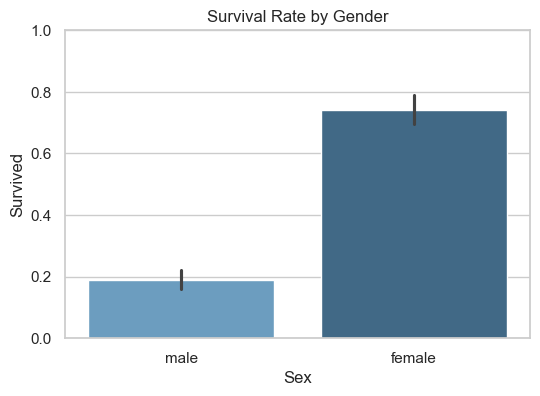

In [20]:
# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)

# 1. Survival rate by Sex
plt.figure()
sns.barplot(x="Sex", y="Survived", hue="Sex", data=train_raw, palette="Blues_d", legend=False)
plt.title("Survival Rate by Gender")
plt.ylim(0, 1)
plt.show()

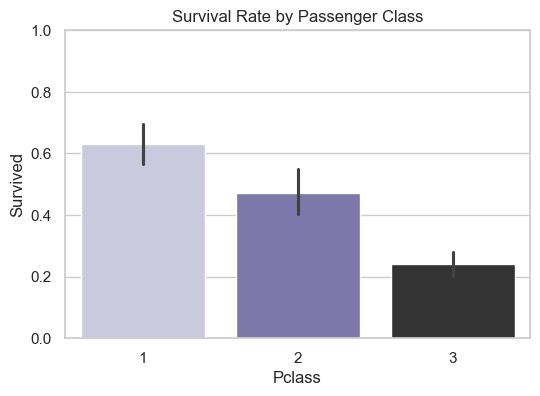

In [21]:
# 2. Survival rate by Passenger Class (Pclass)
plt.figure()
sns.barplot(x="Pclass", y="Survived", hue="Pclass", data=train_raw, palette="Purples_d", legend=False)
plt.title("Survival Rate by Passenger Class")
plt.ylim(0, 1)
plt.show()

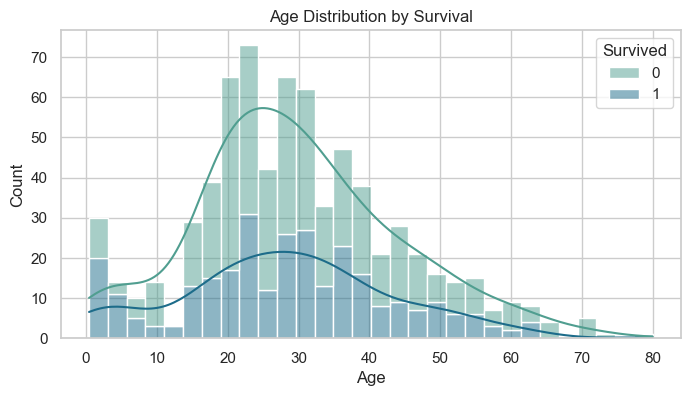

In [22]:
# 3. Age distribution of survivors vs non-survivors
plt.figure(figsize=(8, 4))
sns.histplot(x="Age", hue="Survived", data=train_raw, multiple="stack", kde=True, bins=30, palette="crest")
plt.title("Age Distribution by Survival")
plt.show()

## 3. 🧼 Data Preprocessing

We clean the data, fill missing values (imputing Age using the median grouped by Class and Sex, filling Embarked with the mode, and Fare with the median), and drop columns like Cabin, Ticket, and Name.

In [23]:
print("Missing values in Train before preprocessing:")
print(train_raw.isnull().sum())

# We run feature engineering's engineer() first because it extracts Title from Name, and clean() drops Name!
train_fe = engineer(train_raw.copy())
test_fe = engineer(test_raw.copy())

train_clean = clean(train_fe)
test_clean = clean(test_fe)

print("\nMissing values in Train after preprocessing:")
print(train_clean.isnull().sum())
print(f"\nTrain clean shape: {train_clean.shape}")

Missing values in Train before preprocessing:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in Train after preprocessing:
PassengerId        0
Survived           0
Pclass             0
Sex                0
Age                0
SibSp              0
Parch              0
Fare               0
Title              0
FamilySize         0
IsAlone            0
FareBand           0
AgeBand            0
Deck               0
TicketGroupSize    0
Sex_Pclass         0
Embarked_Q         0
Embarked_S         0
dtype: int64

Train clean shape: (891, 18)


## 4. 🛠️ Feature Engineering & Selection

We select the best engineered features (such as `Title`, `FamilySize`, `IsAlone`, `AgeBand`, `FareBand`) to use in our ML models.

In [24]:
print("Columns in cleaned DataFrame:")
print(train_clean.columns.tolist())

feature_cols = select_features(train_clean)
print(f"\nSelected features ({len(feature_cols)}): {feature_cols}")

X_train = train_clean[feature_cols]
y_train = train_clean["Survived"]
X_test = test_clean[feature_cols]

Columns in cleaned DataFrame:
['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Title', 'FamilySize', 'IsAlone', 'FareBand', 'AgeBand', 'Deck', 'TicketGroupSize', 'Sex_Pclass', 'Embarked_Q', 'Embarked_S']

Selected features (14): ['Pclass', 'Sex', 'AgeBand', 'FareBand', 'FamilySize', 'IsAlone', 'Title', 'Deck', 'TicketGroupSize', 'Sex_Pclass', 'Embarked_Q', 'Embarked_S', 'SibSp', 'Parch']


## 5. 🌲 Baseline Model Training

We build and cross-validate our baseline Random Forest classifier.

In [11]:
print("Building and training baseline Random Forest model...")
rf_model = build_baseline_model("random_forest")
rf_cv = cross_validate_model(rf_model, X_train, y_train, cv=5)

# Fit model on the full training set
rf_model = train_model(rf_model, X_train, y_train)

  CV 5-fold accuracy: 0.8283 ± 0.0101
  Individual folds: ['0.8436', '0.8146', '0.8202', '0.8315', '0.8315']


## 6. 📈 Model Evaluation

We evaluate the Random Forest model on the training set using multiple diagnostic tools (confusion matrix, feature importances, ROC curve, and classification report).

In [12]:
y_train_pred = predict(rf_model, X_train)
print("Training Set Performance:")
accuracy_score(y_train, y_train_pred)

print_classification_report(y_train, y_train_pred)

Training Set Performance:
  Accuracy : 0.8451  (84.51%)

  Classification Report:
                   precision    recall  f1-score   support
  
  Did not survive       0.84      0.92      0.88       549
         Survived       0.85      0.73      0.78       342
  
         accuracy                           0.85       891
        macro avg       0.85      0.82      0.83       891
     weighted avg       0.85      0.85      0.84       891
  


Plotting Confusion Matrix...


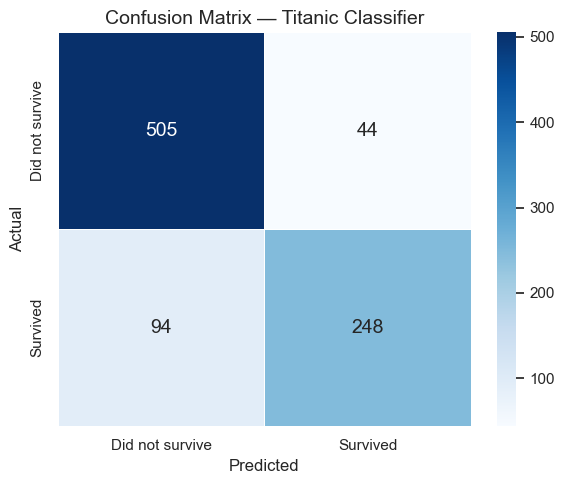

In [13]:
print("Plotting Confusion Matrix...")
plot_confusion_matrix(y_train, y_train_pred, save=False)

Plotting Feature Importances...


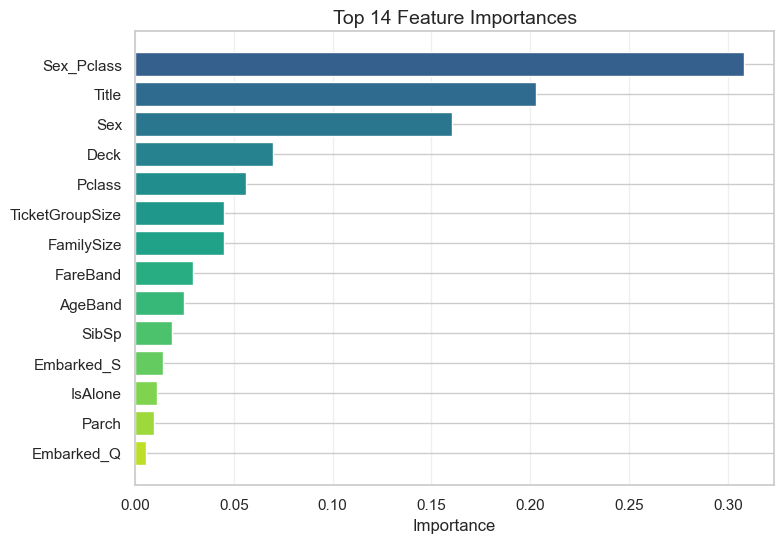

In [14]:
print("Plotting Feature Importances...")
plot_feature_importance(rf_model, feature_cols, top_n=len(feature_cols), save=False)

Plotting ROC Curve...


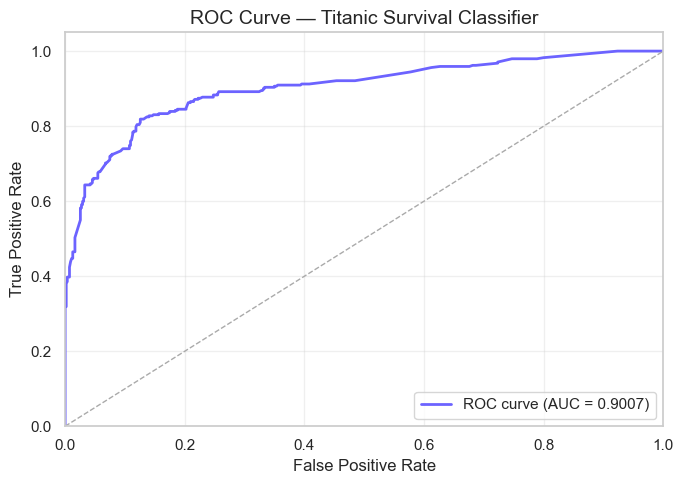

  ROC-AUC  : 0.9007


In [15]:
if hasattr(rf_model, "predict_proba"):
    y_prob = rf_model.predict_proba(X_train)[:, 1]
    print("Plotting ROC Curve...")
    roc_auc(y_train, y_prob, save=False)

## 7. ⚖️ Model Comparison

Let's compare the performance of four different algorithms using 5-fold stratified cross-validation:
1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. XGBoost


-- Logistic Regression --
  CV 5-fold accuracy: 0.8092 ± 0.0095
  Individual folds: ['0.8156', '0.7978', '0.7978', '0.8146', '0.8202']

-- Random Forest --
  CV 5-fold accuracy: 0.8283 ± 0.0101
  Individual folds: ['0.8436', '0.8146', '0.8202', '0.8315', '0.8315']

-- Gradient Boosting --
  CV 5-fold accuracy: 0.8238 ± 0.0155
  Individual folds: ['0.8436', '0.8258', '0.8034', '0.8371', '0.8090']

-- Xgboost --
  CV 5-fold accuracy: 0.8328 ± 0.0122
  Individual folds: ['0.8492', '0.8427', '0.8146', '0.8315', '0.8258']

Plotting Model Comparison...


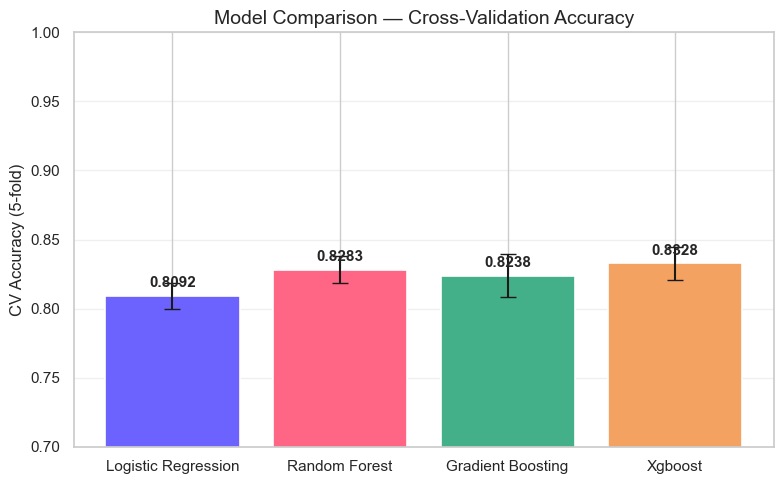

In [16]:
models_to_compare = ["logistic_regression", "random_forest", "gradient_boosting", "xgboost"]
comparison_results = {}

for mtype in models_to_compare:
    label = mtype.replace("_", " ").title()
    print(f"\n-- {label} --")
    model = build_baseline_model(mtype)
    res = cross_validate_model(model, X_train, y_train, cv=5)
    comparison_results[label] = res

print("\nPlotting Model Comparison...")
compare_models(comparison_results, save=False)

## 8. 💾 Generate Submission

We train our best model (Random Forest, based on cross-validation results) on the entire training set, predict survival on the test set, and save the result in the format expected by Kaggle.

In [17]:
best_model_name = "random_forest"
print(f"Training final {best_model_name.replace('_', ' ').title()} model...")
best_model = build_baseline_model(best_model_name)
best_model = train_model(best_model, X_train, y_train)

# Predict on test set
y_test_pred = predict(best_model, X_test)

# Create submission DataFrame
submission = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": y_test_pred.astype(int)
})

# Save submission file
save_submission(submission, "../submissions/rf_submission_v1.csv")

Training final Random Forest model...
[OK] Submission saved -> ../submissions/rf_submission_v1.csv  (418 rows)
